# Random_Forest #

In [2]:
# import librearies:
import pandas as pd

In [3]:
# read .csv:
dataset = pd.read_csv('insurance_pre.csv')
dataset.head()

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


In [4]:
dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
dataset.shape

(1338, 6)

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 62.8+ KB


In [8]:
dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
charges     0
dtype: int64

In [9]:
# Data Pre-Processing:
# one_hot_Encoding:
dataset = pd.get_dummies(dataset,drop_first = True,dtype = int)
dataset.head()

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,0,1
1,18,33.770,1,1725.55230,1,0
2,28,33.000,3,4449.46200,1,0
3,33,22.705,0,21984.47061,1,0
4,32,28.880,0,3866.85520,1,0


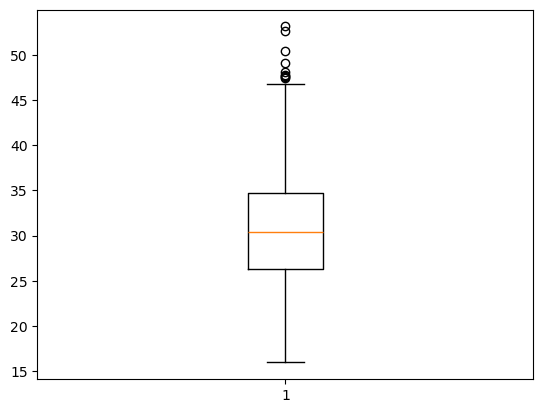

In [10]:
import matplotlib.pyplot as plt
plt.boxplot(dataset[['bmi']])
plt.show()

In [11]:
# IQR Method:
q1 = dataset['bmi'].quantile(0.25)
q3 = dataset['bmi'].quantile(0.75)
IQR = q3 - q1

lower = q1 - 1.5 * IQR
higher = q3 + 1.5 * IQR

dataset['bmi'] = dataset['bmi'].clip(lower,higher)
dataset['bmi']

0       27.900
1       33.770
2       33.000
3       22.705
4       28.880
         ...  
1333    30.970
1334    31.920
1335    36.850
1336    25.800
1337    29.070
Name: bmi, Length: 1338, dtype: float64

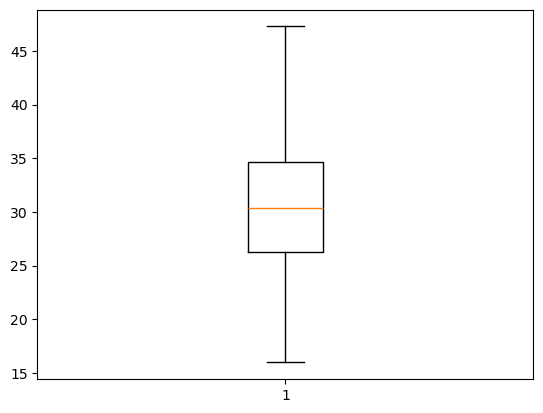

In [12]:
# After outlier treatment:
plt.boxplot(dataset['bmi'])
plt.show()

In [13]:
# log transformation:
import numpy as np 
dataset['charges_log'] = np.log1p(dataset['charges'])
dataset['charges_log']

0        9.734236
1        7.453882
2        8.400763
3        9.998137
4        8.260455
          ...    
1333     9.268755
1334     7.699381
1335     7.396847
1336     7.605365
1337    10.279948
Name: charges_log, Length: 1338, dtype: float64

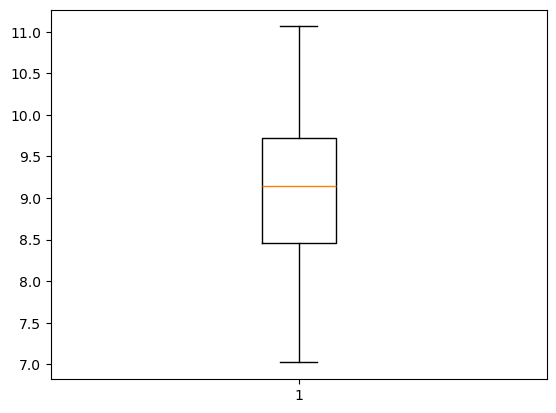

In [14]:
plt.boxplot(dataset['charges_log'])
plt.show()

In [15]:
dataset = dataset.drop('charges',axis = 1)
dataset

,age,bmi,children,sex_male,smoker_yes,charges_log
0,19,27.900,0,0,1,9.734236
1,18,33.770,1,1,0,7.453882
2,28,33.000,3,1,0,8.400763
3,33,22.705,0,1,0,9.998137
4,32,28.880,0,1,0,8.260455
...,...,...,...,...,...,...
1333,50,30.970,3,1,0,9.268755
1334,18,31.920,0,0,0,7.699381
1335,18,36.850,0,0,0,7.396847
1336,21,25.800,0,0,0,7.605365


In [16]:
# split input and output:
independent = dataset[['age','bmi','children','sex_male','smoker_yes']]
dependent = dataset[['charges_log']]

In [17]:
# split train and test dataset: 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(independent,dependent,test_size=0.2,random_state=4)

In [18]:
# Fetch the model:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
pipe = Pipeline([('model',RandomForestRegressor()
          )])


In [53]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
    # 'n_estimators':200,
    # 'max_depth':15,
    # 'min_samples_leaf'=4,
    # 'min_samples_split'=10,
    # 'random_state'=0
}

SyntaxError: cannot assign to literal here. Maybe you meant '==' instead of '='? (2074686263.py, line 6)

In [20]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
    
)



In [21]:
grid.fit(x_train, y_train)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,),

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('model', RandomForestRegressor())]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200]},
             scoring='r2')

In [22]:
print("Best parameters:", grid.best_params_)
print("Best CV R² score:", grid.best_score_)

Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 100}
Best CV R² score: 0.8338053425825919


In [23]:
best_model = grid.best_estimator_
y_train_pred = best_model.predict(x_train)
from sklearn.metrics import r2_score
train_r2_score = r2_score(y_train,y_train_pred)

y_test_pred = best_model.predict(x_test)
test_r2_score = r2_score(y_test, y_test_pred)

In [24]:
print(f"Train R²: {train_r2_score}")
print(f"Test R²: {test_r2_score}")

Train R²: 0.8979860317406013
Test R²: 0.7880371589945266


In [ ]:
# 0.898 − 0.788 = 0.11
# Mild overfitting, but:

# Not dangerous

# Very common in tree-based models

# Acceptable in practice